In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.optimize import least_squares
from scipy.special import spherical_jn as jn
import emcee
import os
from multiprocessing import Pool
import corner

import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
from utils.lib.constants import *

In [2]:
#%matplotlib widget
#plt.close('all')

# Inferenza bayesiana per modello LO

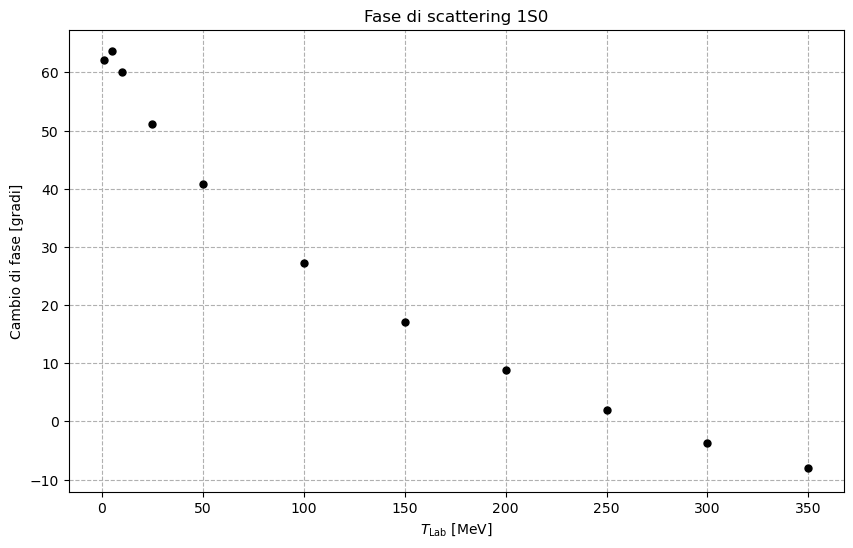

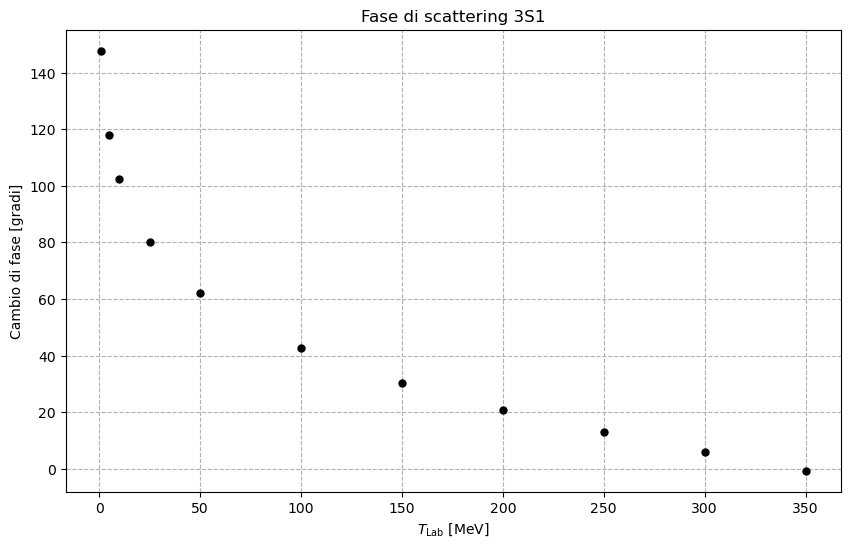

In [47]:
# Leggiamo i dati sperimentali e grafichiamoli per farci un'idea basilare di che aspetto abbiano.

T_Lab = granada.Tlabs # sempre queste per tutte le serie

shift_1S0 = granada.delta_1S0
shift_1S0_error = granada.delta_1S0_errors
shift_3S1 = granada.delta_3S1
shift_3S1_error = granada.delta_3S1_errors
# In approssimazione LO, ci sono le onde 1S0 e 3S1 e solo quelle!

plt.figure(figsize=(10, 6))
plt.errorbar(T_Lab, shift_1S0, yerr = shift_1S0_error, label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=5.)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"Cambio di fase [gradi]")
plt.title("Fase di scattering 1S0")
plt.grid(linestyle = "--")
plt.show()

plt.figure(figsize=(10, 6))
plt.errorbar(T_Lab, shift_3S1, yerr = shift_3S1_error, label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=5.)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"Cambio di fase [gradi]")
plt.title("Fase di scattering 3S1")
plt.grid(linestyle = "--")
plt.show()
# Gli errori ci sono ma così piccoli da non vedersi.

In [4]:
# I dati sperimentali a noi forniti sono quelli dello scattering, quindi sarà su questi che faremo inferenza bayesiana usando emcee.
# In approssimazione LO, il potenziale ha due parametri numerici da valutare: C_1S0 e C_3S1.

# Nell'interazione 3S1 entra in gioco solo il parametro C_3S1, mentre nell'interazione 1S0 entra in gioco solo C_1S0;
# il fastidio è che fare una delle due interazioni dobbiamo comunque inizializzare nn_studio dando valore ad entrambe le costanti.
# I due prior sono indipendenti, ma nota che abbiamo anche due likelihood indipendenti (ed infatti due diversi dataset)!
# Per una spiegazione di com'è implementato emcee e perché, vedere se necessario il mio notebook per l'esperienza 1.

def ln_prior_LO(parameters):
    C_1S0, C_3S1 = parameters
    
    avg_1S0 = 0.0
    avg_3S1 = 0.0
    sigma_1S0 = 5.0
    sigma_3S1 = 5.0

    ln_P_1S0 = -0.5 * ( np.log(2*np.pi * sigma_1S0**2) + ((C_1S0-avg_1S0) / sigma_1S0)**2 )
    ln_P_3S1 = -0.5 * ( np.log(2*np.pi * sigma_3S1**2) + ((C_3S1-avg_3S1) / sigma_3S1)**2 )
    return ln_P_1S0 + ln_P_3S1

def ln_likelihood_LO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1):
    LO_lecs = {}
    LO_lecs["C_1S0"] = parameters[0]
    LO_lecs["C_3S1"] = parameters[1]
    nnstudio.lecs = LO_lecs
    
    nnstudio.compute_Tmtx(chn_1S0, verbose=False)
    teo_1S0 = nnstudio.phase_shifts[0]
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    teo_3S1 = nnstudio.phase_shifts[0][:,0]
    
    ln_L_1S0 = -0.5 * np.sum( np.log(2*np.pi * err_1S0**2) + ((exp_1S0-teo_1S0) / err_1S0)**2 )
    ln_L_3S1 = -0.5 * np.sum( np.log(2*np.pi * err_3S1**2) + ((exp_3S1-teo_3S1) / err_3S1)**2 )
    return ln_L_1S0 + ln_L_3S1

def ln_posterior_LO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1):
    return ln_prior_LO(parameters) + ln_likelihood_LO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1)

# In totale, il teorema di Bayes in forma logaritmica è la somma di due prior e di due likelihood!

In [77]:
# Inizializziamo nn_studio. L'inferenza (per com'è scritta) presume che Tlabs e V siano già stati selezionati, quindi:
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=10, mesh_type="gauleg_finite")
nn.Tlabs = T_Lab
nn.V = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)

_, channel_1S0 = nn.lookup_channel_idx(l=0,ll=0,s=0,j=0) # Il canale 1S0 è il primo orbitale anti-legante, in cui gli spin sono accoppiati (chn_idx=0)
_, channel_3S1 = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1) # Il canale 3S1 è quello del ground state del deutone

In [6]:
# Metodo MCMC:
ndim = 2
nwalkers = 5
nsteps = 800

initial_guess = [-0.10, -0.10] # Prendendo ispirazione dai valori nominali in lec_values, ma deliberatamente scostandoci un po'
starting_positions = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

# Paralleliziamo:
ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            ln_posterior_LO, 
            args=(nn, channel_1S0, shift_1S0, shift_1S0_error, channel_3S1, shift_3S1, shift_3S1_error),
            pool=pool
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(starting_positions, nsteps, progress=True)
    print("\nFinito!")

Eseguendo su 8 core...


100%|██████████| 800/800 [25:24<00:00,  1.91s/it]


Finito!


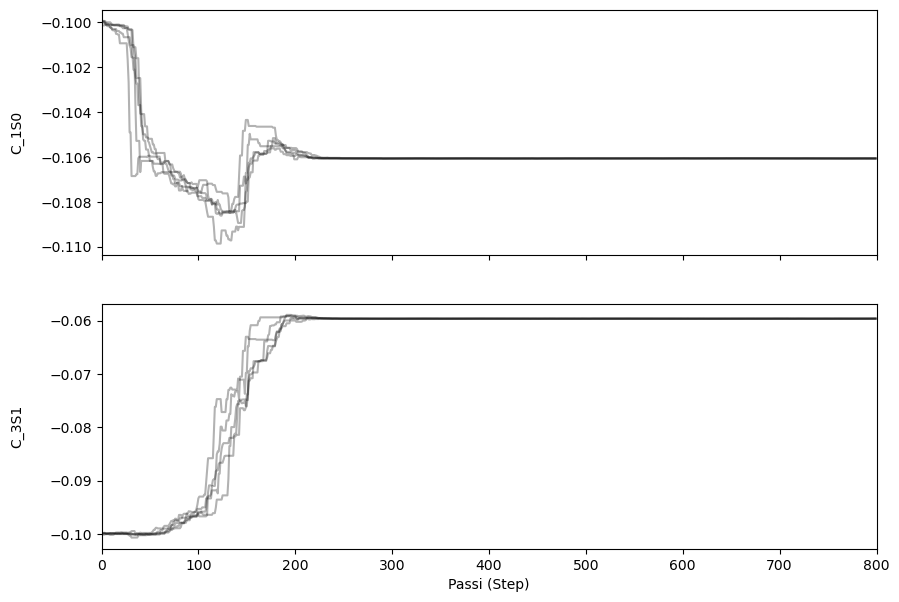

In [74]:
# Verifica della convergenza:
samples = sampler.get_chain()
labels = ["C_1S0", "C_3S1"]
figure, axes = plt.subplots(2, figsize=(10, 7), sharex=True)

for i in range(2):
    inset = axes[i]
    inset.plot(samples[:, :, i], "k", alpha=0.3)
    inset.set_xlim(0, len(samples))
    inset.set_ylabel(labels[i])
    inset.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Passi (Step)")
plt.show()

In [24]:
# Questa cella era un test per verificare la bontà della sovrapposizione del modello sui dati sperimentali,
# di fatto replicando lo script dell'esempio fornitoci. Lasciamo commentato perhé ridondante con quello che verrà dopo.


#C_1S0 = samples[-1, 0, 0] # Non importa il valore del secondo indice, tanto tutti i walkers convergono
#C_3S1 = samples[-1, 0, 1]
#
## Ripetiamo le stesse operazioni dello script di esempio, ma coi nostri valori per le lecs invece di quelli nominali:
#nn.Tlabs = [1e-6] + [x/10 for x in np.arange(1,11,1)]+[x for x in np.arange(2,31,1)] + [x for x in np.arange(40,360,10)]
#LO_lecs = {}
#LO_lecs["C_1S0"] = C_1S0
#LO_lecs["C_3S1"] = C_3S1
#nn.lecs = LO_lecs
#_, selected_channel = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1)
#nn.compute_Tmtx(selected_channel,verbose=False)
#shift_teorico = nn.phase_shifts[0][:,0]
#
#plt.figure(figsize=(10, 6))
#plt.errorbar(T_Lab, shift_3S1, yerr = shift_3S1_error, label = "Dati sperimentali", color="k", ls="none", marker="o", markersize=3.)
#plt.plot(nn.Tlabs, shift_teorico, label = r"$\chi$EFT LO ($\Lambda=500$ MeV)",color="blue",alpha=0.8,lw=2)
#plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
#plt.ylabel(r"Cambio di fase [gradi]")
#plt.title("Fase di scattering 3S1")
#plt.grid(linestyle = "--")
#plt.show()
#
#print(f"\nValore ottenuto per C_1S0 in approssimazione LO: {C_1S0:.6f}\t(valore nominale: {lec_values.lo_lecs["C_1S0"]:.6f})")
#print(f"Valore ottenuto per C_3S1 in approssimazione LO: {C_3S1:.6f}\t(valore nominale: {lec_values.lo_lecs["C_3S1"]:.6f})\n")

### Parametri per emcee
Esistono delle linee guida ben precise su quali parametri usare per le simulazioni MCMC, dettate da giustificazioni teoriche.

La dimensionalità ndim deve chiaramente corrispondere al numero di parametri su cui facciamo inferenza.  
Il numero di walkers nwalkers deve essere almeno il doppio della dimensionalità.  
La lunghezza della catena nsteps deve essere almeno 50 volte il tempo di autocorrelazione più grande.  
Il numero di step iniziali da scartare discard deve essere circa 5 volte il tempo di autocorrelazione più grande.  
L'intervallo di thinning thin dev'essere al massimo il tempo di autocorrelazione più piccolo.  

Come ottenere i tempi di autocorrelazione per ciascun parametro? Si esegue una simulazione preventiva con parametri molto ottimisti ma che almeno sia relativamente veloce (e che converga), e poi si chiede ad emcee di stimare i tempi di autocorrelazione. Da lì, si aggiustano a ritroso i parametri della simulazione e si ottengono i dati veri e propri.

Oltre a tutto questo, nel nostro caso specifico, c'è anche la precisione intrinseca di nn_studio. In particolare, quando inizializziamo l'oggetto, specifichiamo il parametro Np che determina quanto sia fitta la matrice dei momenti considerati (nonché sia la precisione del risultato finale sia il peso computazionale). La prima run preventiva è stata eseguita scegliendo Np=10 ma poi anche questo numero andrà aumentato. Nota, in particolare, che nell'esempio fornito per calcolare i dati di scattering viene usato Np=30 come compromesso tra precisione e prestazione.

In [15]:
tau = sampler.get_autocorr_time()
# Questo metodo restituisce un array, contenente il tempo di autocorrelazione per ciascun parametro.
# In particolare, per il caso LO, i tempi di autocorrelazione sono circa 20 e 90 step.
# Per questo motivo, a ritroso, ci rendiamo conto che la catena per il caso LO dev'essere lunga ben 5000 step!
print(f"\nTempo di autocorrelazione per C_1S0 in approssimazione LO: {tau[0]:.1f} step")
print(f"Tempo di autocorrelazione per C_3S1 in approssimazione LO: {tau[1]:.1f} step\n")

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 16;
tau: [20.18217062 91.65499479]

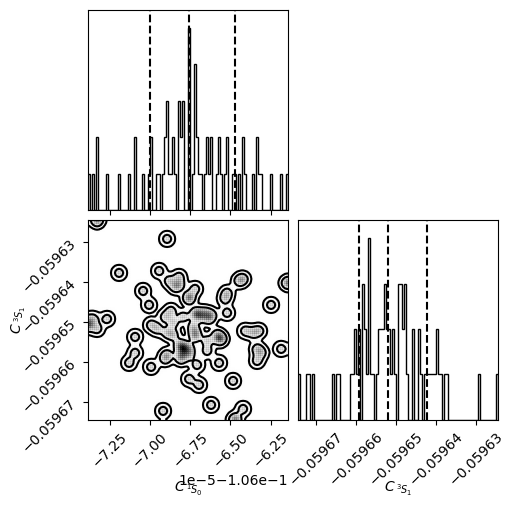

In [75]:
# Similarmente alla scelta della lunghezza, anche la scelta del discard iniziale è dettata dal tempo di autocorrelazione.
# Tipicamente, si scartano l'equivalente dei primi 5 tempi di autocorrelazione (sempre scegliendo il più grande).
# Quindi, sempre a ritroso, ci accorgiamo che è opportuno scartare i primi 500 step circa.
# Seguendo entrambe le convenzioni su lunghezza e discard, il discard sarà quindi il primo 10% della catena.

# Infine, per il thinning si sceglie l'arrotondamento di un singolo tempo di autocorrelazione, ma stavolta scegliendo il tempo più piccolo. In questo caso,
# a ritroso il thinning sarà quindi 20 step. Il senso è che per tempi minori di così ci aspettiamo che ciacun walker sia ancora rimasto "fermo sul posto".
# Quindi, con questo thinning, riduciamo la ridondanza dei dati senza perdita di informazione statistica.
flat_samples = sampler.get_chain(discard=500, thin=20, flat=True)

labels = [r"$C\,_{^1S_0}$", r"$C\,_{^3S_1}$"]
figure = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=False, # Consideriamo il lasciarlo a False così da non dover litigare con la formattazione di corner
    title_kwargs={"fontsize": 12},
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=100,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

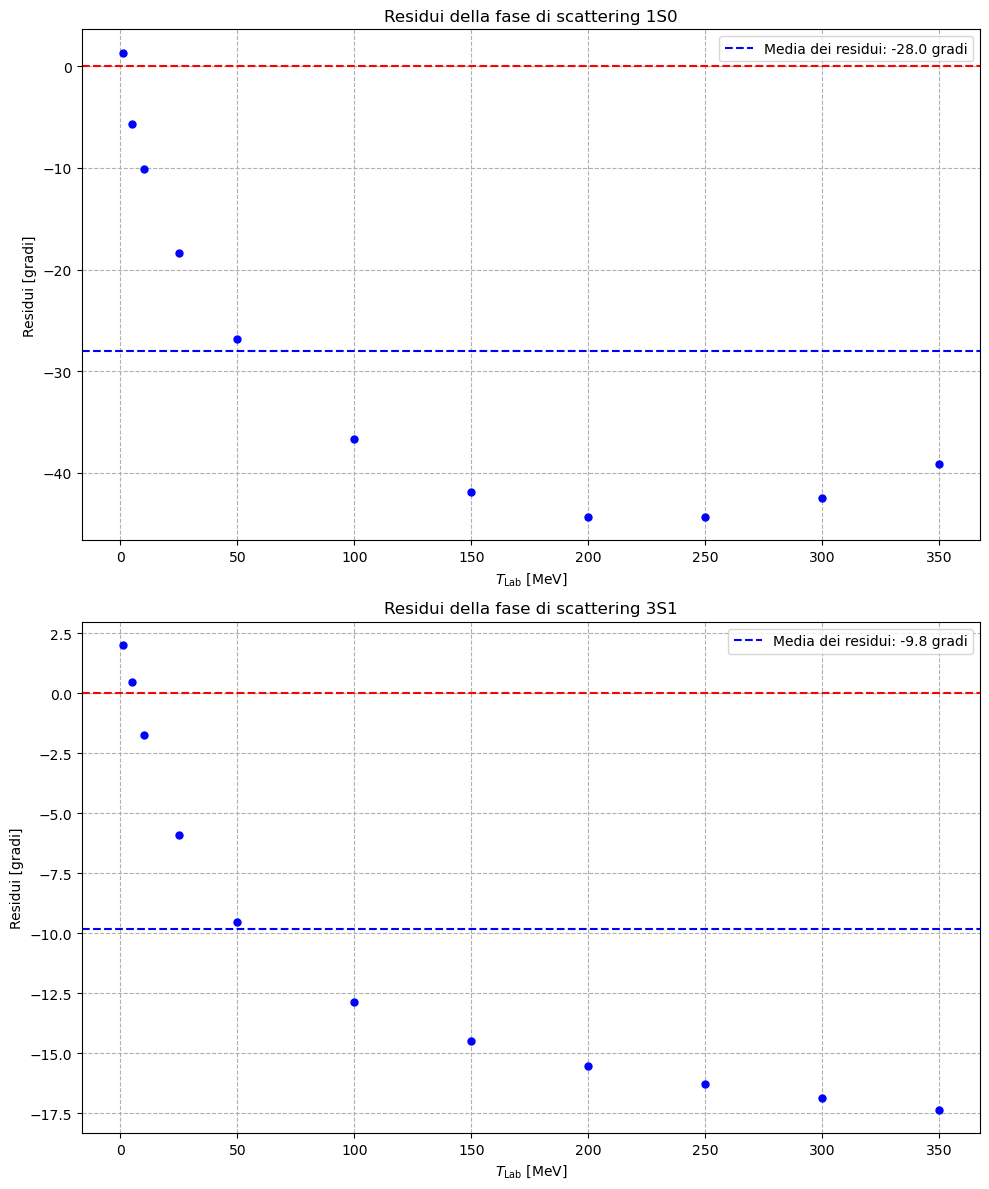

In [80]:
# Infine, come ci è richiesto, vogliamo valutare la distribuzione dei residui del nostro modello.
# Un modello si può formalmente ritenere corretto se e solo se i residui (tra predizioni e misure sperimentali) sono distribuiti attorno allo zero.

# Leggiamo i risultati finali ottenuti da emcee:
C_1S0_median = np.median(flat_samples[:, 0]) ############### QUALCHE MOTIVO PER SCEGLIERE MEDIANA PIUTTOSTO CHE MEDIA?###########
C_1S0_sigma = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16)) ############ QUALCHE MOTIVO PER NON USARE np.var ?####
C_3S1_median = np.median(flat_samples[:, 1])
C_3S1_sigma = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(campioni[:, 1], 16))

# Calcoliamo le predizioni del modello:
#shift_teorico_interp = np.interp(T_Lab, nn.Tlabs, shift_teorico) ############ NON SONO UN FAN DELLE INTERPOLAZIONI #####################
nn.Tlabs = T_Lab
LO_lecs = {}
LO_lecs["C_1S0"] = C_1S0_median
LO_lecs["C_3S1"] = C_3S1_median
nn.lecs = LO_lecs

nn.compute_Tmtx(channel_1S0, verbose=False)
teo_1S0 = nn.phase_shifts[0]
nn.compute_Tmtx(channel_3S1, verbose=False)
teo_3S1 = nn.phase_shifts[0][:,0]

# Calcoliamo i residui:
residuals = []
residuals.append(shift_1S0 - teo_1S0)
residuals.append(shift_3S1 - teo_3S1)

# E infine grafichiamo:
means_res = []
for i in range(len(residuals)):
    means_res.append(np.mean(residuals[i]))
titles = ["1S0", "3S1"]

figure, axes = plt.subplots(2, figsize=(10, 12))
for i in range(2):
    inset = axes[i]
    inset.plot(T_Lab, residuals[i], marker = ".", linestyle = "None", color = "b", markersize = 10.)
    inset.axhline(means_res[i], linestyle= "--", color = "b", label=f"Media dei residui: {means_res[i]:.1f} gradi")
    inset.axhline(0, linestyle= "--", color = "r")
    inset.set_xlabel(r"$T_\mathrm{Lab}$ [MeV]")
    inset.set_ylabel(r"Residui [gradi]")
    inset.set_title(f"Residui della fase di scattering {titles[i]}")
    inset.legend()
    inset.grid(linestyle = "--")
plt.tight_layout()
plt.show()

# Non valuteremo quantitativamente oltre, ma è ben evidente che l'approssimazione LO non sia granché come modello.

# Inferenza bayesiana per modello NLO
Tempo di replicare tutto il codice anche per il caso NLO.

In [81]:
# In approssimazione NLO ci sono ora anche le onde 3D1:
shift_3D1 = granada.delta_3D1
shift_3D1_error = granada.delta_3D1_errors
# E le miscele 3S1-3D1:
shift_mix = granada.delta_3E1
shift_mix_error = granada.delta_3E1_errors

# I canali di questi due nuovi casi sono già contenuti fra i blocchi di channel_3S1: il canale è condiviso perché le due funzioni d'onda sono accoppiate.
# Nel caso LO il nostro nn_studio si calcolava lo scattering per tutti i casi del canale, ma a noi interessava solo il primo blocco,
# quello con l=0, ll=0. In parole povere, prendevamo solo nnstudio.phase_shifts[0][:,0] dentro la likelihood: questo perché
# quello è il blocco in alto a sinistra della matrice del potenziale ed è quello che corrisponde alla onda 3S1 "pura".

# Stavolta invece ci interesserà guardare anche agli altri blocchi. Il quarto blocco corrisponde alla 3D1 pura, mentre i due blocchi di mezzo
# sono uguali tra loro e si riferiscono alla miscela 3S1-3D1. Nota che i blocchi della miscela sono simmetrici e quindi il codice li scrive una volta sola.

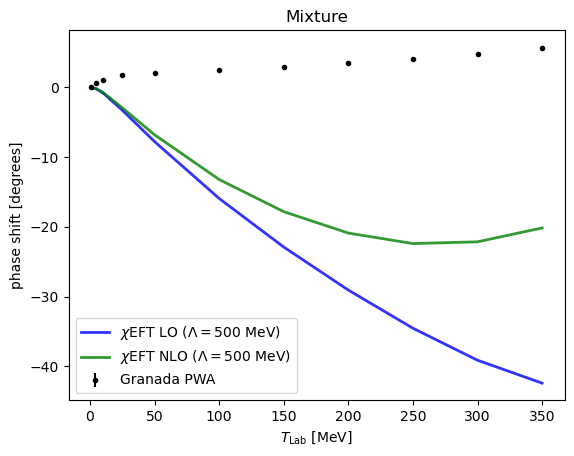

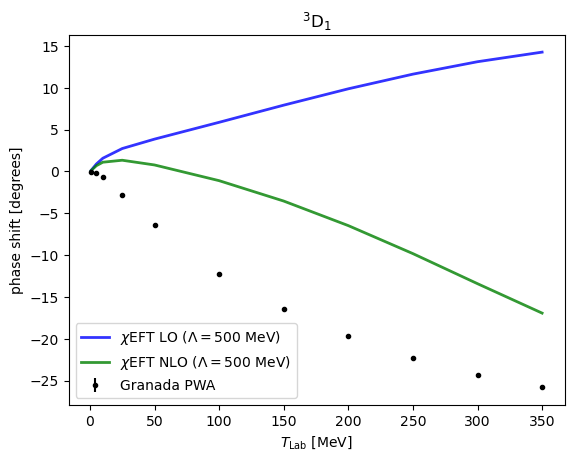

In [82]:
# Grafichiamo, per reference, i dati sperimentali per le nuove funzioni d'onda, insieme ai fit nominali:
nn.Tlabs = T_Lab
nn.V = chiral_potential.two_nucleon_potential("LO",Lambda=500.0)
nn.lecs = lec_values.lo_lecs
nn.compute_Tmtx(selected_channel,verbose=False)
LO_mix = nn.phase_shifts[0][:,1] # Nota come cambiamo l'ultimo indice
LO_3D1 = nn.phase_shifts[0][:,2]

nn.V = chiral_potential.two_nucleon_potential("NLO",Lambda=500.0)
nn.lecs = lec_values.nlo_lecs
nn.compute_Tmtx(selected_channel,verbose=False)
NLO_mix = nn.phase_shifts[0][:,1]
NLO_3D1 = nn.phase_shifts[0][:,2]

plt.errorbar(T_Lab,shift_mix, yerr=shift_mix_error,label = "Granada PWA", color="k",ls="none",marker="o",markersize=3.)
plt.plot(T_Lab,LO_mix, label = r"$\chi$EFT LO ($\Lambda=500$ MeV)",color="blue",alpha=0.8,lw=2)
plt.plot(T_Lab,NLO_mix, label = r"$\chi$EFT NLO ($\Lambda=500$ MeV)",color="green",alpha=0.8,lw=2)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"phase shift [degrees]")
plt.title(r"Mixture")
plt.legend()
plt.show()

plt.errorbar(T_Lab,shift_3D1, yerr=shift_3D1_error,label = "Granada PWA", color="k",ls="none",marker="o",markersize=3.)
plt.plot(T_Lab,LO_3D1, label = r"$\chi$EFT LO ($\Lambda=500$ MeV)",color="blue",alpha=0.8,lw=2)
plt.plot(T_Lab,NLO_3D1, label = r"$\chi$EFT NLO ($\Lambda=500$ MeV)",color="green",alpha=0.8,lw=2)
plt.xlabel(r"$T_\mathrm{Lab}$ [MeV]")
plt.ylabel(r"phase shift [degrees]")
plt.title(r"$^3$D$_1$")
plt.legend()
plt.show()

In [83]:
# La generalizzazione di emcee sarà esattamente come ce la aspettiamo. Stavolta abbiamo 5 prior e 4 likelihood.

def ln_prior_NLO(parameters):
    C_1S0, C_3S1, D_1S0, D_3S1, D_mix = parameters
    
    avg_C1S0 = 0.0
    avg_C3S1 = 0.0
    avg_D1S0 = 0.0
    avg_D3S1 = 0.0
    avg_Dmix = 0.0
    sigma_C1S0 = 5.0
    sigma_C3S1 = 5.0
    sigma_D1S0 = 5.0
    sigma_D3S1 = 5.0
    sigma_Dmix = 5.0

    ln_C1S0 = -0.5 * ( np.log(2*np.pi * sigma_C1S0**2) + ((C_1S0-avg_C1S0) / sigma_C1S0)**2 )
    ln_C3S1 = -0.5 * ( np.log(2*np.pi * sigma_C3S1**2) + ((C_3S1-avg_C3S1) / sigma_C3S1)**2 )
    ln_D1S0 = -0.5 * ( np.log(2*np.pi * sigma_D1S0**2) + ((D_1S0-avg_D1S0) / sigma_D1S0)**2 )
    ln_D3S1 = -0.5 * ( np.log(2*np.pi * sigma_D3S1**2) + ((D_3S1-avg_D3S1) / sigma_D3S1)**2 )
    ln_Dmix = -0.5 * ( np.log(2*np.pi * sigma_Dmix**2) + ((D_mix-avg_Dmix) / sigma_Dmix)**2 )
    return ln_C1S0 + ln_C3S1 + ln_D1S0 + ln_D3S1 + ln_Dmix

def ln_likelihood_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    NLO_lecs = {}
    NLO_lecs["C_1S0"] = parameters[0]
    NLO_lecs["C_3S1"] = parameters[1]
    NLO_lecs["D_1S0"] = parameters[2]
    NLO_lecs["D_3S1"] = parameters[3]
    NLO_lecs["D_3S1-3D1"] = parameters[4]
    
    # Non abbiamo i dati sperimentali delle onde per i parametri rimanenti. Questo vuol dire che per essi prendiamo
    # dei valori nominali, e facciamo inferenza solo sui parametri che possiamo confrontare con gli esperimenti.
    NLO_lecs["D_1P1"] = 0.7
    NLO_lecs["D_3P0"] = 1.5
    NLO_lecs["D_3P1"] = -0.6
    NLO_lecs["D_3P2"] = -0.5
    nnstudio.lecs = NLO_lecs
    
    nnstudio.compute_Tmtx(chn_1S0, verbose=False)
    teo_1S0 = nnstudio.phase_shifts[0]
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    teo_3S1 = nnstudio.phase_shifts[0][:,0]
    teo_mix = nnstudio.phase_shifts[0][:,1]
    teo_3D1 = nnstudio.phase_shifts[0][:,2]
    
    ln_L_1S0 = -0.5 * np.sum( np.log(2*np.pi * err_1S0**2) + ((exp_1S0-teo_1S0) / err_1S0)**2 )
    ln_L_3S1 = -0.5 * np.sum( np.log(2*np.pi * err_3S1**2) + ((exp_3S1-teo_3S1) / err_3S1)**2 )
    ln_L_mix = -0.5 * np.sum( np.log(2*np.pi * err_mix**2) + ((exp_mix-teo_mix) / err_mix)**2 )
    ln_L_3D1 = -0.5 * np.sum( np.log(2*np.pi * err_3D1**2) + ((exp_3D1-teo_3D1) / err_3D1)**2 )
    return ln_L_1S0 + ln_L_3S1 + ln_L_mix + ln_L_3D1

def ln_posterior_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix):
    ln_post = ln_prior_NLO(parameters)
    ln_post += ln_likelihood_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix)
    return ln_post 

In [85]:
# Metodo MCMC:
ndim = 5
nwalkers = 10
nsteps = 1000

initial_guess = [-0.10, -0.10, 1.0, -1.0, 0.1]
starting_positions = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

ncpu = os.cpu_count()
if __name__ == "__main__":
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            ln_posterior_NLO, 
            args=(nn, channel_1S0, shift_1S0, shift_1S0_error, channel_3S1, shift_3S1, shift_3S1_error, shift_3D1, shift_3D1_error, shift_mix, shift_mix_error),
            pool=pool
        )
        print(f"Eseguendo su {ncpu} core...")
        sampler.run_mcmc(starting_positions, nsteps, progress=True)
    print("\nFinito!")

Eseguendo su 8 core...


  0%|          | 3/1000 [00:41<3:35:05, 12.94s/it]Process ForkPoolWorker-24:
Process ForkPoolWorker-21:
Process ForkPoolWorker-22:
Process ForkPoolWorker-17:
Process ForkPoolWorker-23:
Process ForkPoolWorker-18:
Process ForkPoolWorker-20:
Process ForkPoolWorker-19:
Traceback (most recent call last):
  File "/home/dave/anaconda3/lib/python3.13/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_6011/4121020853.py", line 55, in ln_posterior_NLO
    ln_post += ln_likelihood_NLO(parameters, nnstudio, chn_1S0, exp_1S0, err_1S0, chn_3S1, exp_3S1, err_3S1, exp_3D1, err_3D1, exp_mix, err_mix)
               ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_6011/4121020853.py", line 42, in ln_likelihood_NLO
    nnstudio.compute_Tmtx(chn_3S1, verbose=False)
    ~~~~~~~~~~~~

emcee: Exception while calling your likelihood function:
  params: [-0.09999934 -0.10012872  0.9999822  -1.00007792  0.10001911]
  args: (<utils.lib.nn_studio.nn_studio object at 0x7ff3a2b3f110>, [[{'l': 0, 'll': 0, 's': 0, 'j': 0, 't': 1, 'tz': 0, 'pi': 1, 'chn_idx': 0}]], array([62.07659, 63.66045, 60.02014, 51.0708 , 40.88493, 27.21011,
       17.10006,  8.83047,  1.97071, -3.61817, -8.04425]), array([0.01832, 0.04398, 0.0626 , 0.09867, 0.14734, 0.2305 , 0.26576,
       0.26739, 0.2811 , 0.34394, 0.45311]), [[{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}]], array([147.64721, 117.9535 , 102.29182,  80.1358 ,  62.16019,  42.71247,
        30.3921 ,  20.93573,  12.94459,   5.83733,  -0.64397]), array([0.01008, 0.02214, 0.03053, 0.04423, 

KeyboardInterrupt: 

In [ ]:
# Verifica della convergenza:
samples = sampler.get_chain()
labels = ["C_1S0", "C_3S1", "D_1S0", "D_3S1", "D_mix"]
figure, axes = plt.subplots(5, figsize=(15, 15), sharex=True)

for i in range(5):
    inset = axes[i]
    inset.plot(samples[:, :, i], "k", alpha=0.3)
    inset.set_xlim(0, len(samples))
    inset.set_ylabel(labels[i])
    inset.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Passi (Step)")
plt.show()

In [72]:
# Stampa dei tempi di autocorrelazione:
tau = sampler.get_autocorr_time()
print(f"\nTempo di autocorrelazione per C_1S0 in approssimazione NLO: {tau[0]:.1f} step")
print(f"Tempo di autocorrelazione per C_3S1 in approssimazione NLO: {tau[1]:.1f} step")
print(f"Tempo di autocorrelazione per D_1S0 in approssimazione NLO: {tau[2]:.1f} step")
print(f"Tempo di autocorrelazione per D_3S1 in approssimazione NLO: {tau[3]:.1f} step")
print(f"Tempo di autocorrelazione per D_mix in approssimazione NLO: {tau[4]:.1f} step\n")

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 16;
tau: [20.18217062 91.65499479]

In [ ]:
# Stampa dei corner plot:
flat_samples = sampler.get_chain(discard=500, thin=20, flat=True)

labels = [r"$C\,_{^1S_0}$", r"$C\,_{^3S_1}$", r"$D\,_{^1S_0}$", r"$D\,_{^3S_1}$", r"$D_{\mathrm{mix}}$"]
figure = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=False,
    title_kwargs={"fontsize": 12},
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=True,
    bins=100,
    smooth=2.0,
    levels=(0.68, 0.95)
    #fill_contours=True,
    #color="royalblue"
)
plt.show()

In [ ]:
# Visualizzazione dei residui:
C_1S0_median = np.median(flat_samples[:, 0])
C_1S0_sigma = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16))
C_3S1_median = np.median(flat_samples[:, 1])
C_3S1_sigma = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(campioni[:, 1], 16))
D_1S0_median = np.median(flat_samples[:, 2])
D_1S0_sigma = 0.5 * (np.percentile(flat_samples[:, 2], 84) - np.percentile(flat_samples[:, 2], 16))
D_3S1_median = np.median(flat_samples[:, 3])
D_3S1_sigma = 0.5 * (np.percentile(flat_samples[:, 3], 84) - np.percentile(flat_samples[:, 3], 16))
D_mix_median = np.median(flat_samples[:, 4])
D_mix_sigma = 0.5 * (np.percentile(flat_samples[:, 4], 84) - np.percentile(flat_samples[:, 4], 16))


nn.Tlabs = T_Lab
NLO_lecs = {}
NLO_lecs["C_1S0"] = C_1S0_median
NLO_lecs["C_3S1"] = C_3S1_median
NLO_lecs["D_1S0"] = D_1S0_median
NLO_lecs["D_3S1"] = D_3S1_median
NLO_lecs["D_3S1-3D1"] = D_mix_median
NLO_lecs["D_1P1"] = 0.7
NLO_lecs["D_3P0"] = 1.5
NLO_lecs["D_3P1"] = -0.6
NLO_lecs["D_3P2"] = -0.5
nn.lecs = NLO_lecs
nn.compute_Tmtx(channel_1S0, verbose=False)
teo_1S0 = nn.phase_shifts[0]
nn.compute_Tmtx(channel_3S1, verbose=False)
teo_3S1 = nn.phase_shifts[0][:,0]
teo_mix = nn.phase_shifts[0][:,1]
teo_3D1 = nn.phase_shifts[0][:,2]


residuals = []
residuals.append(shift_1S0 - teo_1S0)
residuals.append(shift_3S1 - teo_3S1)
residuals.append(shift_mix - teo_mix)
residuals.append(shift_3D1 - teo_3D1)
means_res = []
for i in range(len(residuals)):
    means_res.append(np.mean(residuals[i]))
titles = ["1S0", "3S1", "mix", "3D1"]

figure, axes = plt.subplots(4, figsize=(10, 24))
for i in range(4):
    inset = axes[i]
    inset.plot(T_Lab, residuals[i], marker = ".", linestyle = "None", color = "b", markersize = 10.)
    inset.axhline(means_res[i], linestyle= "--", color = "b", label=f"Media dei residui: {means_res[i]:.1f} gradi")
    inset.axhline(0, linestyle= "--", color = "r")
    inset.set_xlabel(r"$T_\mathrm{Lab}$ [MeV]")
    inset.set_ylabel(r"Residui [gradi]")
    inset.set_title(f"Residui della fase di scattering {titles[i]}")
    inset.legend()
    inset.grid(linestyle = "--")
plt.tight_layout()
plt.show()